<a href="https://colab.research.google.com/github/ticketyboo18/nlp-literary-analysis/blob/main/nlpfinalpbl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 NLP-Based Literary Analysis of Classic Books
### End Semester Project | Natural Language Processing

**Student:** Mukta Pande, Arnav Maindola  |  **Enrollment No.:** 23119019, 23119021  |

---
> **Abstract:** This project implements a complete NLP pipeline on a multi-author book corpus, covering text preprocessing, Boolean information retrieval using an inverted index, part-of-speech stylometric analysis, named entity recognition, and unsupervised topic discovery via Latent Dirichlet Allocation (LDA).

## Section 1 — Environment Setup & Library Installation
Installing required libraries: `datasets`, `nltk`, `spacy`, `gensim`, and `pyLDAvis`. NLTK corpora (punkt, stopwords, wordnet, POS tagger) are also downloaded here.

In [ ]:
!pip install -q datasets nltk spacy gensim pyLDAvis
!python -m spacy download en_core_web_sm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 3.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import spacy
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis
from datasets import load_dataset

## Section 2 — Dataset Loading
Loading the `IsmaelMousa/books` dataset from HuggingFace. Train and validation splits are merged into a single DataFrame. Null entries in the text column are dropped to prevent downstream errors.

In [ ]:
dataset = load_dataset("IsmaelMousa/books")
df = pd.concat(
    [dataset["train"].to_pandas(), dataset["validation"].to_pandas()],
    ignore_index=True
)

df = df.dropna(subset=['EN']).reset_index(drop=True)

print(f"Total books loaded: {len(df)}\n")
print(f"{'#':<4} {'Title':<45} {'Author':<30} {'Category'}")
print("─" * 100)
for i, row in df.iterrows():
    print(f"{i+1:<4} {row['title']:<45} {row['author']:<30} {row['category']}")

Total books loaded: 49

#    Title                                         Author                         Category
────────────────────────────────────────────────────────────────────────────────────────────────────
1    Robinson Crusoe                               Daniel Defoe                   Adventure
2    The Adventures of Tom Sawyer                  Mark Twain (Samuel Clemens)    Adventure
3    The Mysterious Island                         Anthony Hope                   Adventure
4    Treasure Island                               Robert Louis Stevenson         Adventure
5    The Life of James Watt                        Edward Bellamy                 Biographies
6    The Life of Julius Caesar                     Herman Melville                Biographies
7    Little Women                                  Louisa May Alcott              Children's Books
8    Peter Pan                                     James M. Barrie                Children's Books
9    The Adventures of Alice i

## Section 3 — Text Preprocessing: Tokenization & Lemmatization
**Pipeline steps:**
1. Lowercase and truncate text to 50,000 characters
2. Word tokenization using NLTK `word_tokenize`
3. Remove non-alphabetic tokens and stopwords
4. POS tagging using the Penn Treebank tagset
5. Context-aware lemmatization using WordNet (verbs, adjectives, adverbs handled separately from nouns)

**Key metric added:** Type-Token Ratio (TTR) = unique tokens / total tokens — measures lexical richness per author.

In [ ]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def get_pos(tag):
    """Map Penn Treebank POS tags to WordNet POS constants."""
    if tag.startswith('V'): return wordnet.VERB
    if tag.startswith('J'): return wordnet.ADJ
    if tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def preprocess(text, max_chars=50000):
    """
    Full preprocessing pipeline:
      1. Truncate text to max_chars
      2. Lowercase & tokenize
      3. Remove non-alpha tokens
      4. Remove stopwords
      5. POS-aware lemmatization
    """
    tokens = word_tokenize(text[:max_chars].lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    tagged = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(t, get_pos(tag)) for t, tag in tagged]

example_sentence = "The detective carefully examined the mysterious dark room"
ex_tokens = word_tokenize(example_sentence.lower())
ex_tokens = [t for t in ex_tokens if t.isalpha() and t not in stop_words]
ex_tagged = nltk.pos_tag(ex_tokens)
ex_lemmas = [lemmatizer.lemmatize(t, get_pos(tag)) for t, tag in ex_tagged]

print("\n─── Preprocessing Demo ───")
print(f"Original  : {example_sentence}")
print(f"Tokens    : {ex_tokens}")
print(f"POS tags  : {ex_tagged}")
print(f"Lemmatized: {ex_lemmas}")

# Apply to all books
df['tokens'] = df['EN'].apply(preprocess)

#Added type-token ratio (TTR) as a lexical richness metric
print("\n─── Vocabulary Stats ───")
print(f"{'Author':<30} {'Tokens':>8} {'Unique':>8} {'TTR':>6}")
print("─" * 56)
for _, row in df.iterrows():
    toks   = row['tokens']
    unique = len(set(toks))
    ttr    = round(unique / len(toks), 3) if toks else 0
    print(f"{row['author']:<30} {len(toks):>8} {unique:>8} {ttr:>6}")


─── Preprocessing Demo ───
Original  : The detective carefully examined the mysterious dark room
Tokens    : ['detective', 'carefully', 'examined', 'mysterious', 'dark', 'room']
POS tags  : [('detective', 'JJ'), ('carefully', 'RB'), ('examined', 'VBN'), ('mysterious', 'JJ'), ('dark', 'NN'), ('room', 'NN')]
Lemmatized: ['detective', 'carefully', 'examine', 'mysterious', 'dark', 'room']

─── Vocabulary Stats ───
Author                           Tokens   Unique    TTR
────────────────────────────────────────────────────────
Daniel Defoe                       4126     1339  0.325
Mark Twain (Samuel Clemens)        4286     1724  0.402
Anthony Hope                       4259     1580  0.371
Robert Louis Stevenson             4315     1408  0.326
Edward Bellamy                     3945     1693  0.429
Herman Melville                    4134     1787  0.432
Louisa May Alcott                  4585     1605   0.35
James M. Barrie                    4102     1315  0.321
Lewis Carroll           

##Section 4 — Boolean Information Retrieval
An **inverted index** maps each lemmatized term to the set of book titles containing it. Boolean queries are supported:

| Operator | Operation | Example |
|----------|-----------|---------|
| `AND` | Set intersection | `murder and detective` |
| `OR` | Set union | `island or sea` |
| `AND NOT` | Set difference | `love and not war` |

> **Note:** Query terms are automatically lemmatized before lookup, so `"murders"` correctly matches the indexed form `"murder"`.

In [ ]:
# Build inverted index: word → set of book titles
index = defaultdict(set)
for _, row in df.iterrows():
    for word in set(row['tokens']):
        index[word].add(row['title'])

print(f"\nIndex built: {len(index)} unique terms indexed.\n")

def search(query: str) -> set:
    """
    Boolean search over the inverted index.
    Query terms are lemmatized automatically so raw user input works.
    Supports: AND, OR, AND NOT  (case-insensitive)
    """
    q = query.strip().lower()

    def normalize(term):
        """Lemmatize a single search term."""
        tok = [t for t in word_tokenize(term) if t.isalpha() and t not in stop_words]
        tagged = nltk.pos_tag(tok)
        return lemmatizer.lemmatize(tagged[0][0], get_pos(tagged[0][1])) if tagged else term

    if 'and not' in q:
        a, b   = q.split('and not', 1)
        result = index[normalize(a.strip())] - index[normalize(b.strip())]
    elif ' and ' in q:
        parts  = [p.strip() for p in q.split(' and ')]
        result = index[normalize(parts[0])]
        for p in parts[1:]:
            result = result & index[normalize(p)]
    elif ' or ' in q:
        parts  = [p.strip() for p in q.split(' or ')]
        result = set()
        for p in parts:
            result = result | index[normalize(p)]
    else:
        result = index[normalize(q)]

    label = result if result else {'— No books found —'}
    print(f"Query: '{query}'  →  {label}")
    return result

search("murders and detectives")
search("island or sea")
search("sherlock")
search("murder and detective")
search("love and not war")
search("murder or crime")

#Shows top-10 most frequent index terms (corpus vocabulary peek)
print("\n─── Top 10 Most Indexed Terms ───")
term_freq = sorted(index.items(), key=lambda x: len(x[1]), reverse=True)[:10]
for term, titles in term_freq:
    print(f"  '{term}' → appears in {len(titles)} book(s)")


Index built: 16238 unique terms indexed.

Query: 'murders and detectives'  →  {'— No books found —'}
Query: 'island or sea'  →  {'The Hunchback of Notre Dame', 'The War in the Air', 'The Count of Monte Cristo', 'The Island of Doctor Moreau', 'The Mysterious Island', 'Wuthering Heights', 'Robinson Crusoe', 'Lady Susan', 'The Moonstone', 'Moby Dick', 'The Adventures of the Five Orange Pips', 'North and South', 'Frankenstein', 'The Wind in the Willows', 'The Secret Adversary', 'Jane Eyre', 'A Tale of Two Cities', 'The Fellowship of the Ring', 'The Pickwick Papers', 'Persuasion', 'Great Expectations', 'Peter Pan', 'The Adventures of Alice in Wonderland', 'The Woman in White', 'Treasure Island', '20000 Leagues Under the Sea'}
Query: 'sherlock'  →  {'The Adventures of Sherlock Holmes', 'The Hound of the Baskervilles'}
Query: 'murder and detective'  →  {'— No books found —'}
Query: 'love and not war'  →  {'The Adventures of Tom Sawyer', 'The Mystery of the Yellow Room', 'The Hound of the Bas

## Section 5 — Part-of-Speech Stylometric Analysis
POS distribution is used as a **stylometric fingerprint** — different authors and genres have characteristic ratios of nouns, verbs, adjectives, and adverbs.

- High noun density → descriptive or expository prose
- High verb density → action-driven narrative
- High adjective density → atmospheric or Gothic writing

Results are visualized as a grouped bar chart across all authors.


─── POS Tagging Demo ───
Sentence: Sherlock carefully examined the dark mysterious room
  Sherlock        → NNP
  carefully       → RB
  examined        → VBD
  the             → DT
  dark            → NN
  mysterious      → JJ
  room            → NN

NN=Noun  VB=Verb  JJ=Adjective  RB=Adverb

Author                           Nouns%   Verbs%    Adj%    Adv%
──────────────────────────────────────────────────────────────
Daniel Defoe                       45.1     16.7    19.7     9.4
Mark Twain (Samuel Clemens)        47.8     16.2    21.4     8.2
Anthony Hope                       48.4     16.5    21.9     6.7
Robert Louis Stevenson             45.2     17.2    20.9     8.7
Edward Bellamy                     45.6     16.4    21.6     9.0
Herman Melville                    47.5     11.9    23.8     9.2
Louisa May Alcott                  44.2     17.4    24.9     6.9
James M. Barrie                    40.7     20.3    19.4     9.2
Lewis Carroll                      38.0     19.4    23.9

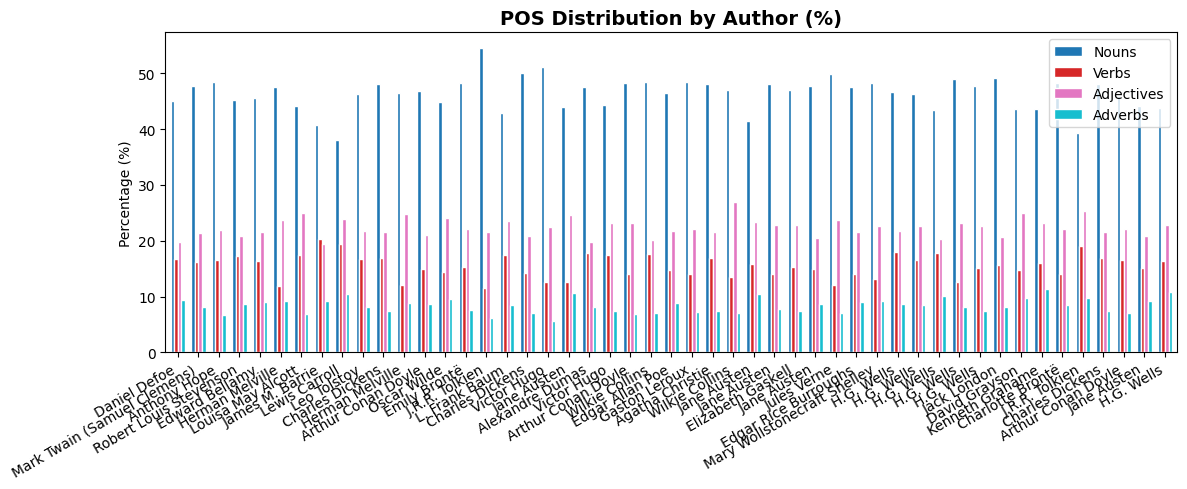

Chart saved → pos_distribution.png


In [ ]:
sample = "Sherlock carefully examined the dark mysterious room"
tagged = nltk.pos_tag(nltk.word_tokenize(sample))
print("\n─── POS Tagging Demo ───")
print(f"Sentence: {sample}")
for word, tag in tagged:
    print(f"  {word:<15} → {tag}")
print("\nNN=Noun  VB=Verb  JJ=Adjective  RB=Adverb\n")

def pos_profile(tokens, cap=2000):
    tagged = nltk.pos_tag(tokens[:cap])
    total  = len(tagged) or 1
    return {
        'Nouns':    round(sum(1 for _, t in tagged if t.startswith('NN')) / total * 100, 1),
        'Verbs':    round(sum(1 for _, t in tagged if t.startswith('VB')) / total * 100, 1),
        'Adjectives': round(sum(1 for _, t in tagged if t.startswith('JJ')) / total * 100, 1),
        'Adverbs':  round(sum(1 for _, t in tagged if t.startswith('RB')) / total * 100, 1),
    }

profiles = []
print(f"{'Author':<30} {'Nouns%':>8} {'Verbs%':>8} {'Adj%':>7} {'Adv%':>7}")
print("─" * 62)
for _, row in df.iterrows():
    p = pos_profile(row['tokens'])
    p['author'] = row['author']
    profiles.append(p)
    print(f"{row['author']:<30} {p['Nouns']:>8} {p['Verbs']:>8} {p['Adjectives']:>7} {p['Adverbs']:>7}")

# Bar chart — POS distribution per author
pos_df = pd.DataFrame(profiles).set_index('author')
ax = pos_df[['Nouns','Verbs','Adjectives','Adverbs']].plot(
    kind='bar', figsize=(12, 5), colormap='tab10', edgecolor='white', width=0.7
)
ax.set_title('POS Distribution by Author (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('pos_distribution.png', dpi=150)
plt.show()
print("Chart saved → pos_distribution.png")

## Section 6 — Sentence Length Analysis (spaCy)
Using spaCy's `en_core_web_sm` sentence segmentation to compute per-author sentence length statistics:
- **Average sentence length** (words/sentence) — measures prose complexity
- **Standard deviation** — measures rhythmic consistency of writing style
- **Sentence count** — corpus coverage indicator

In [ ]:
nlp = spacy.load("en_core_web_sm")

print("\n─── Sentence Length Analysis ───")
print(f"{'Author':<30} {'Avg Len':>9} {'Std Dev':>9} {'# Sents':>9}")
print("─" * 60)

sent_stats = []
for _, row in df.iterrows():
    doc   = nlp(row['EN'][:10000])
    sents = [s for s in doc.sents if len(s) > 1]
    if not sents:
        continue
    lens   = [len(s) for s in sents]
    avg    = round(sum(lens) / len(lens), 1)
    std    = round(pd.Series(lens).std(), 1)
    sent_stats.append({'author': row['author'], 'avg': avg, 'std': std, 'n': len(sents)})
    print(f"{row['author']:<30} {avg:>9} {std:>9} {len(sents):>9}")


─── Sentence Length Analysis ───
Author                           Avg Len   Std Dev   # Sents
────────────────────────────────────────────────────────────
Daniel Defoe                        90.6      90.5        25
Mark Twain (Samuel Clemens)         15.4      12.5       165
Anthony Hope                        23.0      21.6       101
Robert Louis Stevenson              36.9      23.0        64
Edward Bellamy                      29.2      16.9        78
Herman Melville                     33.8      25.7        66
Louisa May Alcott                   24.4      15.1       102
James M. Barrie                     31.8      22.6        72
Lewis Carroll                       32.0      29.6        78
Leo Tolstoy                         22.9      18.4       101
Charles Dickens                     23.6      23.1       105
Herman Melville                     25.0      20.0        91
Arthur Conan Doyle                  18.9      15.5       124
Oscar Wilde                         18.8      17.7 

## Section 7 — Named Entity Recognition (NER)
spaCy's pre-trained NER model identifies real-world entities in each book. We track four entity types:

| Entity Type | Meaning |
|-------------|---------|
| `PERSON` | Character and author names |
| `GPE` | Geopolitical entities (countries, cities) |
| `LOC` | Non-GPE locations (seas, mountains) |
| `ORG` | Organisations and institutions |

Entity percentages reveal whether a book is **character-centric** (high PERSON) or **place-centric** (high GPE/LOC).

In [ ]:
print("\n─── Named Entity Recognition ───")
entity_types = ['PERSON', 'GPE', 'LOC', 'ORG']
ner_rows = []

for _, row in df.iterrows():
    doc = nlp(row['EN'][:15000])
    counts = Counter(ent.label_ for ent in doc.ents if ent.label_ in entity_types)
    total  = sum(counts.values()) or 1
    entry  = {'author': row['author'], 'category': row['category']}
    entry.update({k: round(counts.get(k, 0) / total * 100, 1) for k in entity_types})

    # Top 5 named persons
    persons = [ent.text for ent in doc.ents if ent.label_ == 'PERSON']
    top5    = [w for w, _ in Counter(persons).most_common(5)]
    entry['top_persons'] = ', '.join(top5)
    ner_rows.append(entry)

    print(f"\n{row['author']} [{row['category']}]")
    for et in entity_types:
        print(f"  {et:<8}: {entry[et]:>5}%")
    print(f"  Top persons: {entry['top_persons']}")


─── Named Entity Recognition ───

Daniel Defoe [Adventure]
  PERSON  :  35.3%
  GPE     :  47.1%
  LOC     :   0.0%
  ORG     :  17.6%
  Top persons: Bob, CHAPTER I. START IN LIFE, Robinson, Robinson Kreutznaer, Lockhart

Mark Twain (Samuel Clemens) [Adventure]
  PERSON  :  88.2%
  GPE     :   1.5%
  LOC     :   0.0%
  ORG     :  10.3%
  Top persons: Tom, Jim, don, Tom s, Sid

Anthony Hope [Adventure]
  PERSON  :  75.2%
  GPE     :   3.3%
  LOC     :   0.0%
  ORG     :  21.6%
  Top persons: Medland, Lady Eynesford, Heseltine, Robert, Alicia

Robert Louis Stevenson [Adventure]
  PERSON  :  83.3%
  GPE     :   3.3%
  LOC     :   6.7%
  ORG     :   6.7%
  Top persons: Bill, Livesey, Yo-ho-ho, Benbow, s chest--

Edward Bellamy [Biographies]
  PERSON  :  56.5%
  GPE     :  33.9%
  LOC     :   0.0%
  ORG     :   9.7%
  Top persons: Mathewson, Sturgis, Annie, Hunt, Potts

Herman Melville [Biographies]
  PERSON  :  20.0%
  GPE     :  37.5%
  LOC     :   0.0%
  ORG     :  42.5%
  Top persons: 

## Section 8 — Latent Dirichlet Allocation (LDA) Topic Modelling
LDA is an **unsupervised probabilistic model** that discovers latent themes across the corpus.

**Assumptions:**
- Each document is a mixture of K topics
- Each topic is a probability distribution over vocabulary terms

**Configuration:** `num_topics = 5`, `passes = 15`, `random_state = 42`

Results show the **full topic probability distribution** per book (not just the dominant topic), making it possible to identify books that span multiple themes. The interactive `pyLDAvis` visualization plots topics in 2D — circle size encodes prevalence, distance encodes distinctiveness.

In [ ]:
texts      = df['tokens'].tolist()
dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(no_below=3, no_above=0.8)
corpus = [dictionary.doc2bow(t) for t in texts]

lda = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=5, passes=15,        # more passes → more stable topics
    random_state=42,
    eval_every=None,
    chunksize=10,
)

print("\n─── LDA Topics (top 7 words each) ───")
for i, topic in lda.print_topics(num_words=7):
    words = [w.split('"')[1] for w in topic.split('+')]
    print(f"  Topic {i}: {', '.join(words)}")

print("\n─── Per-Book Topic Distribution ───")
print(f"{'Author':<30} {'Category':<18} {'Dominant Topic':>14}  {'Probabilities'}")
print("─" * 90)
for i, row in df.iterrows():
    topics   = sorted(lda.get_document_topics(corpus[i]), key=lambda x: -x[1])
    dominant = f"Topic {topics[0][0]}"
    prob_str = "  ".join(f"T{t}:{p:.2f}" for t, p in topics)
    print(f"{row['author']:<30} {row['category']:<18} {dominant:>14}  {prob_str}")

# Interactive visualisation
pyLDAvis.enable_notebook()
pyLDAvis.display(gensimvis.prepare(lda, corpus, dictionary))


─── LDA Topics (top 7 words each) ───
  Topic 0: father, lady, sir, miss, mother, family, reply
  Topic 1: joe, captain, sea, ship, sister, leg, boat
  Topic 2: hall, strange, towards, table, fire, horse, sir
  Topic 3: mary, child, mother, girl, th, darling, bed
  Topic 4: rat, dog, along, tree, water, white, wild

─── Per-Book Topic Distribution ───
Author                         Category           Dominant Topic  Probabilities
──────────────────────────────────────────────────────────────────────────────────────────
Daniel Defoe                   Adventure                 Topic 0  T0:0.57  T1:0.38  T4:0.05
Mark Twain (Samuel Clemens)    Adventure                 Topic 4  T4:0.70  T0:0.21  T1:0.07  T3:0.02
Anthony Hope                   Adventure                 Topic 0  T0:0.81  T4:0.13  T1:0.04  T2:0.02
Robert Louis Stevenson         Adventure                 Topic 2  T2:0.42  T1:0.25  T4:0.22  T0:0.09  T3:0.02
Edward Bellamy                 Biographies               Topic 0  T0:0